In [1]:

import numpy as np
import pandas as pd


import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        pass



In [2]:
import os
from PIL import Image
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from glob import glob
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Flatten
from tensorflow.keras.optimizers import Adamax
from tensorflow.keras.metrics import Precision, Recall
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import warnings
warnings.filterwarnings("ignore")
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from scipy.stats import zscore
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import accuracy_score, classification_report,roc_curve, auc
from sklearn.preprocessing import StandardScaler, label_binarize

2025-05-14 15:47:51.926895: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1747237672.122650      19 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1747237672.178987      19 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


In [3]:
classes, class_paths = zip(*[(label, os.path.join('/kaggle/input/brain-tumor-mri-dataset/Training', label, image))
                             for label in os.listdir('/kaggle/input/brain-tumor-mri-dataset/Training') if os.path.isdir(os.path.join('/kaggle/input/brain-tumor-mri-dataset/Training', label))
                             for image in os.listdir(os.path.join('/kaggle/input/brain-tumor-mri-dataset/Training', label))])

tr_df = pd.DataFrame({'Class Path': class_paths, 'Class': classes})
tr_df

,Class Path,Class
0,/kaggle/input/brain-tumor-mri-dataset/Training...,pituitary
1,/kaggle/input/brain-tumor-mri-dataset/Training...,pituitary
2,/kaggle/input/brain-tumor-mri-dataset/Training...,pituitary
3,/kaggle/input/brain-tumor-mri-dataset/Training...,pituitary
4,/kaggle/input/brain-tumor-mri-dataset/Training...,pituitary
...,...,...
5707,/kaggle/input/brain-tumor-mri-dataset/Training...,glioma
5708,/kaggle/input/brain-tumor-mri-dataset/Training...,glioma
5709,/kaggle/input/brain-tumor-mri-dataset/Training...,glioma
5710,/kaggle/input/brain-tumor-mri-dataset/Training...,glioma


In [4]:
classes, class_paths = zip(*[(label, os.path.join('/kaggle/input/brain-tumor-mri-dataset/Testing', label, image))
                             for label in os.listdir('/kaggle/input/brain-tumor-mri-dataset/Testing') if os.path.isdir(os.path.join('/kaggle/input/brain-tumor-mri-dataset/Testing', label))
                             for image in os.listdir(os.path.join('/kaggle/input/brain-tumor-mri-dataset/Testing', label))])

ts_df = pd.DataFrame({'Class Path': class_paths, 'Class': classes})
ts_df

,Class Path,Class
0,/kaggle/input/brain-tumor-mri-dataset/Testing/...,pituitary
1,/kaggle/input/brain-tumor-mri-dataset/Testing/...,pituitary
2,/kaggle/input/brain-tumor-mri-dataset/Testing/...,pituitary
3,/kaggle/input/brain-tumor-mri-dataset/Testing/...,pituitary
4,/kaggle/input/brain-tumor-mri-dataset/Testing/...,pituitary
...,...,...
1306,/kaggle/input/brain-tumor-mri-dataset/Testing/...,glioma
1307,/kaggle/input/brain-tumor-mri-dataset/Testing/...,glioma
1308,/kaggle/input/brain-tumor-mri-dataset/Testing/...,glioma
1309,/kaggle/input/brain-tumor-mri-dataset/Testing/...,glioma


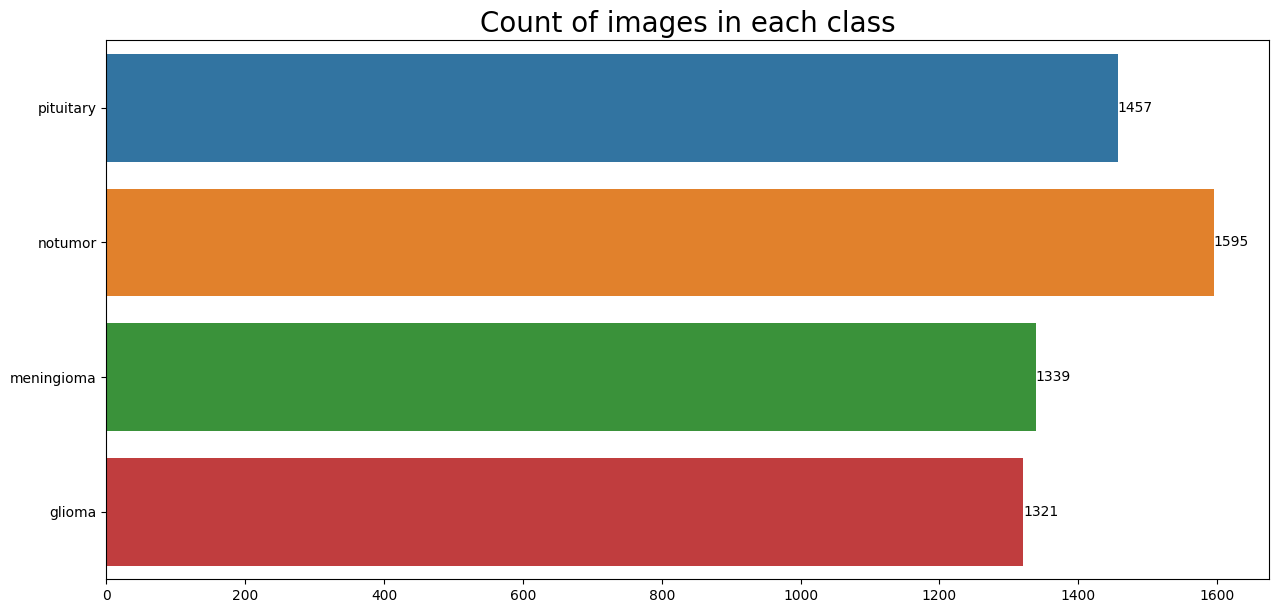

In [5]:
plt.figure(figsize=(15,7))
ax = sns.countplot(data=tr_df , y=tr_df['Class'])

plt.xlabel('')
plt.ylabel('')
plt.title('Count of images in each class', fontsize=20)
ax.bar_label(ax.containers[0])
plt.show()

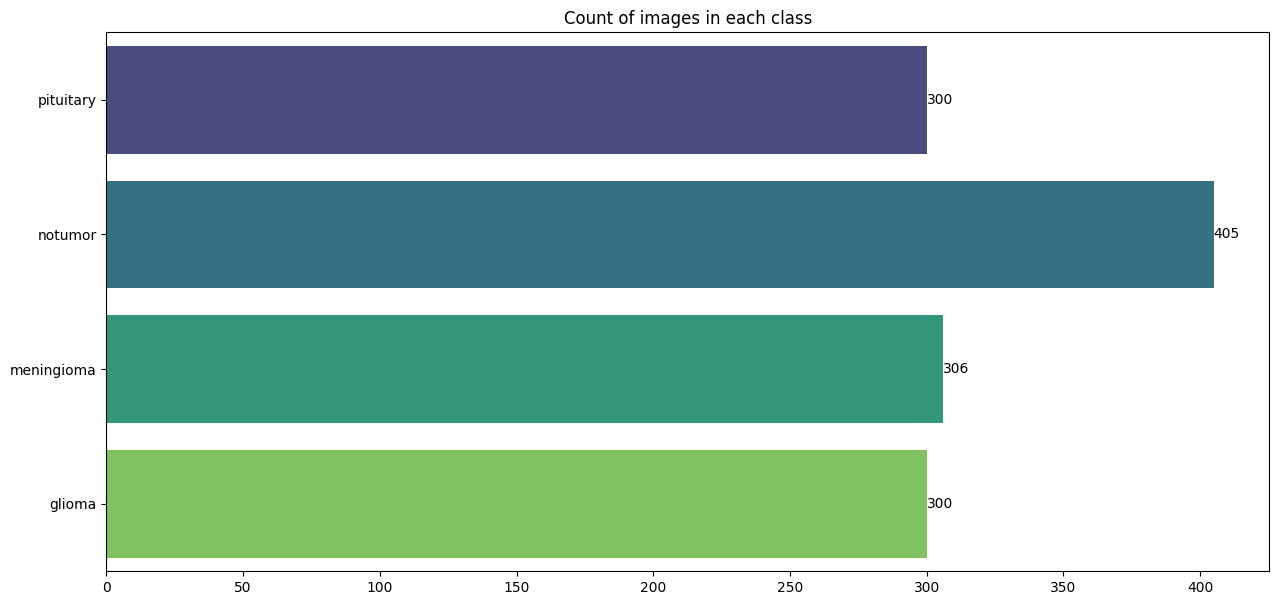

In [6]:
plt.figure(figsize=(15, 7))
ax = sns.countplot(y=ts_df['Class'], palette='viridis')

ax.set(xlabel='', ylabel='', title='Count of images in each class')
ax.bar_label(ax.containers[0])

plt.show()

In [7]:
valid_df, ts_df = train_test_split(ts_df, train_size=0.5, random_state=20, stratify=ts_df['Class'])

In [8]:
batch_size = 32
img_size = (299, 299)

_gen = ImageDataGenerator(rescale=1/255,
                          brightness_range=(0.8, 1.2))

ts_gen = ImageDataGenerator(rescale=1/255)


tr_gen = _gen.flow_from_dataframe(tr_df, x_col='Class Path',
                                  y_col='Class', batch_size=batch_size,
                                  target_size=img_size)

valid_gen = _gen.flow_from_dataframe(valid_df, x_col='Class Path',
                                     y_col='Class', batch_size=batch_size,
                                     target_size=img_size)

ts_gen = ts_gen.flow_from_dataframe(ts_df, x_col='Class Path',
                                  y_col='Class', batch_size=16,
                                  target_size=img_size, shuffle=False)

Found 5712 validated image filenames belonging to 4 classes.
Found 655 validated image filenames belonging to 4 classes.
Found 656 validated image filenames belonging to 4 classes.


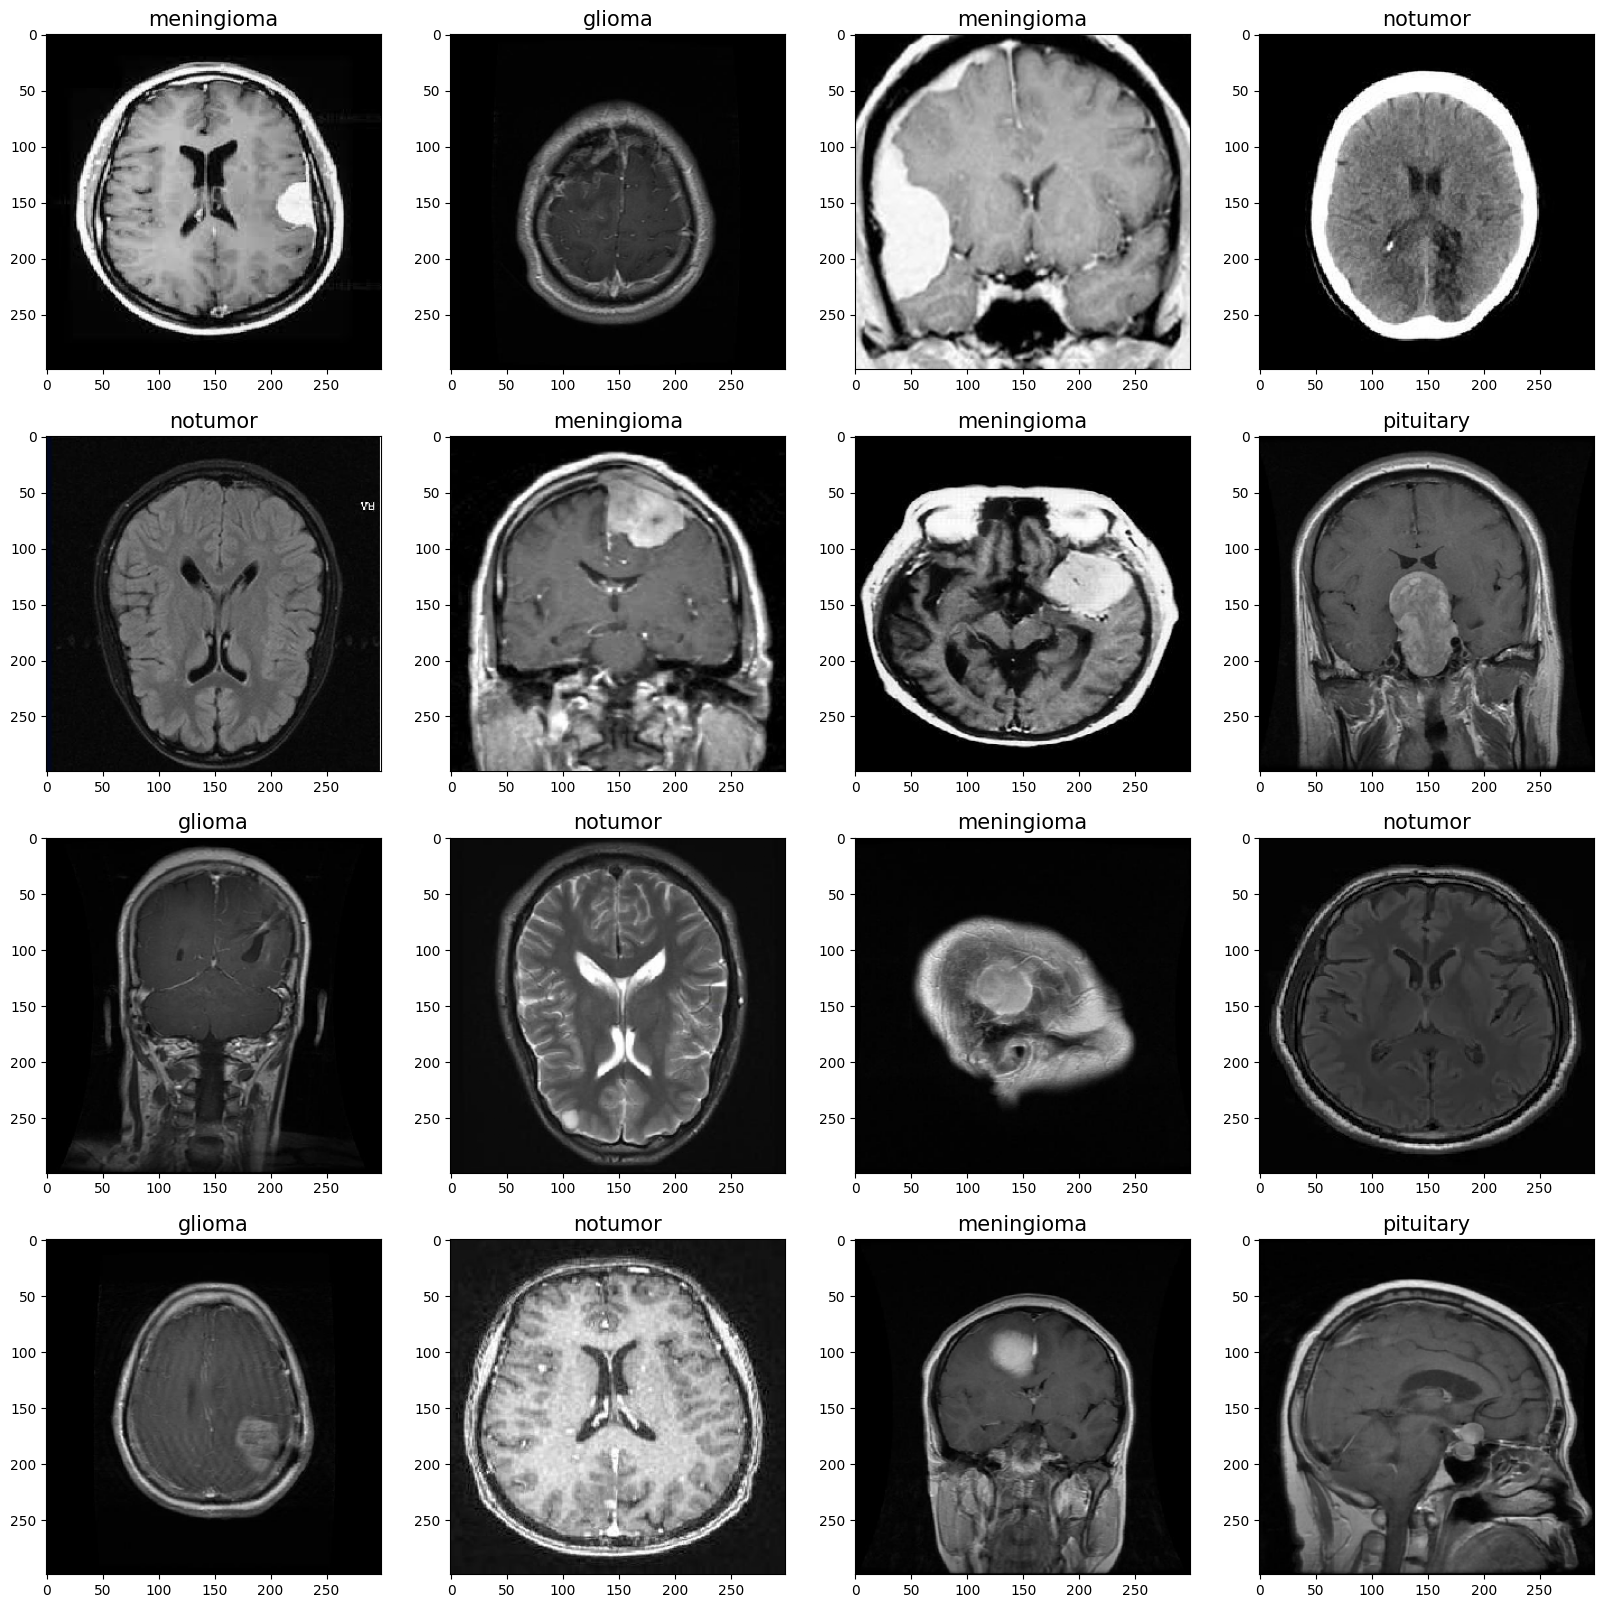

In [9]:
class_dict = tr_gen.class_indices
classes = list(class_dict.keys())
images, labels = next(ts_gen)

plt.figure(figsize=(20, 20))

for i, (image, label) in enumerate(zip(images, labels)):
    plt.subplot(4,4, i + 1)
    plt.imshow(image)
    class_name = classes[np.argmax(label)]
    plt.title(class_name, color='k', fontsize=15)

plt.show()

In [10]:
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

In [11]:
callbacks = [
    EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', patience=5, min_lr=1e-6, verbose=1),
    ModelCheckpoint('best_model.keras', monitor='val_accuracy', save_best_only=True, verbose=1)
]

In [12]:
img_shape=(299,299,3)

base_model = tf.keras.applications.Xception(
    include_top=False,
    weights="imagenet",
    input_shape=img_shape,
    pooling='max'
)

x = base_model.output
x = Flatten()(x)
x = Dropout(rate=0.3)(x)
x = Dense(128, activation='relu')(x)
x = Dropout(rate=0.25)(x)
outputs = Dense(4, activation='softmax')(x)
model = Model(inputs=base_model.input, outputs=outputs)


model.compile(
    optimizer=Adamax(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy', Precision(), Recall()],
)

model.summary()

I0000 00:00:1747237692.009362      19 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15513 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


83683744/83683744 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)              ┃ Output Shape           ┃        Param # ┃ Connected to           ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)  │ (None, 299, 299, 3)    │              0 │ -                      │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ block1_conv1 (Conv2D)     │ (None, 149, 149, 32)   │            864 │ input_layer[0][0]      │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ block1_conv1_bn           │ (None, 149, 149, 32)   │            128 │ block1_conv1[0][0]     │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ block1_conv1_act          │ (None, 149, 149, 32)   │              0 │ block1_conv1_bn[0][0]  │
│ (Activation)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ block1_conv2 (Conv2D)     │ (None, 147, 147, 64)   │         18,432 │ block1_conv1_act[0][0] │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ block1_conv2_bn           │ (None, 147, 147, 64)   │            256 │ block1_conv2[0][0]     │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ block1_conv2_act          │ (None, 147, 147, 64)   │              0 │ block1_conv2_bn[0][0]  │
│ (Activation)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ block2_sepconv1           │ (None, 147, 147, 128)  │          8,768 │ block1_conv2_act[0][0] │
│ (SeparableConv2D)         │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ block2_sepconv1_bn        │ (None, 147, 147, 128)  │            512 │ block2_sepconv1[0][0]  │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ block2_sepconv2_act       │ (None, 147, 147, 128)  │              0 │ block2_sepconv1_bn[0]… │
│ (Activation)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ block2_sepconv2           │ (None, 147, 147, 128)  │         17,536 │ block2_sepconv2_act[0… │
│ (SeparableConv2D)         │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ block2_sepconv2_bn        │ (None, 147, 147, 128)  │            512 │ block2_sepconv2[0][0]  │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d (Conv2D)           │ (None, 74, 74, 128)    │          8,192 │ block1_conv2_act[0][0] │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ block2_pool               │ (None, 74, 74, 128)    │              0 │ block2_sepconv2_bn[0]… │
│ (MaxPooling2D)            │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ batch_normalization  

 Total params: 21,124,268 (80.58 MB)

 Trainable params: 21,069,740 (80.37 MB)

 Non-trainable params: 54,528 (213.00 KB)

In [13]:
tf.keras.utils.plot_model(model, show_shapes=True)

dot: graph is too large for cairo-renderer bitmaps. Scaling by 0.757513 to fit



In [14]:
hist = model.fit(tr_gen,
                 epochs=10,
                 validation_data=valid_gen,
                 callbacks = callbacks,
                 shuffle= False)

Epoch 1/10


I0000 00:00:1747237733.003658      64 service.cc:148] XLA service 0x7a9f6c005b00 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1747237733.004484      64 service.cc:156]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0
I0000 00:00:1747237735.598522      64 cuda_dnn.cc:529] Loaded cuDNN version 90300
E0000 00:00:1747237751.816292      64 gpu_timer.cc:82] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1747237752.055587      64 gpu_timer.cc:82] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1747237753.443135      64 gpu_timer.cc:82] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1747237753.6846

178/179 ━━━━━━━━━━━━━━━━━━━━ 0s 435ms/step - accuracy: 0.7900 - loss: 0.6076 - precision: 0.8536 - recall: 0.7070

E0000 00:00:1747237854.893758      63 gpu_timer.cc:82] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1747237855.102648      63 gpu_timer.cc:82] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1747237856.172200      63 gpu_timer.cc:82] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1747237856.401786      63 gpu_timer.cc:82] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1747237857.316447      63 gpu_timer.cc:82] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:0

179/179 ━━━━━━━━━━━━━━━━━━━━ 0s 565ms/step - accuracy: 0.7906 - loss: 0.6058 - precision: 0.8540 - recall: 0.7080

E0000 00:00:1747237879.987609      64 gpu_timer.cc:82] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1747237880.224057      64 gpu_timer.cc:82] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1747237880.749071      64 gpu_timer.cc:82] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1747237881.009112      64 gpu_timer.cc:82] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.



Epoch 1: val_accuracy improved from -inf to 0.90840, saving model to best_model.keras
179/179 ━━━━━━━━━━━━━━━━━━━━ 184s 662ms/step - accuracy: 0.7912 - loss: 0.6040 - precision: 0.8545 - recall: 0.7089 - val_accuracy: 0.9084 - val_loss: 0.2813 - val_precision: 0.9147 - val_recall: 0.9008 - learning_rate: 0.0010
Epoch 2/10
179/179 ━━━━━━━━━━━━━━━━━━━━ 0s 434ms/step - accuracy: 0.9811 - loss: 0.0580 - precision: 0.9817 - recall: 0.9798
Epoch 2: val_accuracy improved from 0.90840 to 0.98015, saving model to best_model.keras
179/179 ━━━━━━━━━━━━━━━━━━━━ 84s 466ms/step - accuracy: 0.9811 - loss: 0.0580 - precision: 0.9817 - recall: 0.9798 - val_accuracy: 0.9802 - val_loss: 0.0583 - val_precision: 0.9817 - val_recall: 0.9802 - learning_rate: 0.0010
Epoch 3/10
179/179 ━━━━━━━━━━━━━━━━━━━━ 0s 434ms/step - accuracy: 0.9948 - loss: 0.0227 - precision: 0.9948 - recall: 0.9936
Epoch 3: val_accuracy improved from 0.98015 to 0.98779, saving model to best_model.keras
179/179 ━━━━━━━━━━━━━━━━━━━━ 83s

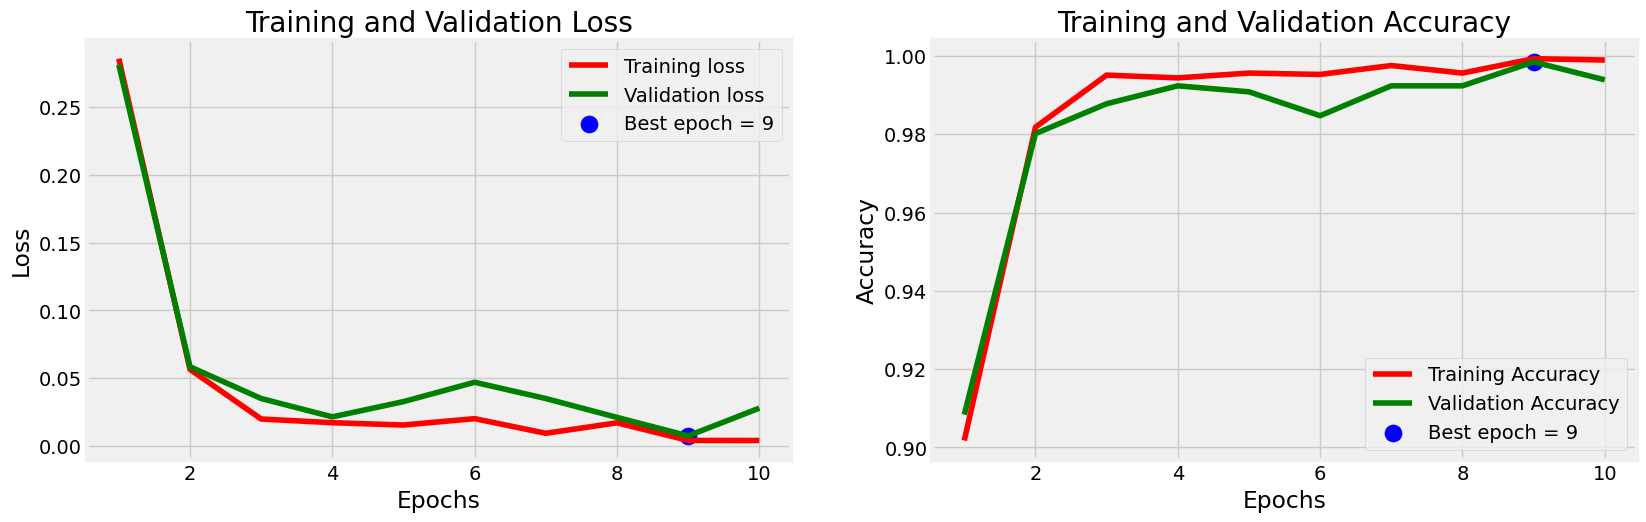

In [15]:
tr_acc = hist.history['accuracy']
tr_loss = hist.history['loss']
tr_per = hist.history['precision']
tr_recall = hist.history['recall']
val_acc = hist.history['val_accuracy']
val_loss = hist.history['val_loss']
val_per = hist.history['val_precision']
val_recall = hist.history['val_recall']

index_loss = np.argmin(val_loss)
val_lowest = val_loss[index_loss]
index_acc = np.argmax(val_acc)
acc_highest = val_acc[index_acc]
index_precision = np.argmax(val_per)
per_highest = val_per[index_precision]
index_recall = np.argmax(val_recall)
recall_highest = val_recall[index_recall]

Epochs = [i + 1 for i in range(len(tr_acc))]
loss_label = f'Best epoch = {str(index_loss + 1)}'
acc_label = f'Best epoch = {str(index_acc + 1)}'
per_label = f'Best epoch = {str(index_precision + 1)}'
recall_label = f'Best epoch = {str(index_recall + 1)}'


plt.figure(figsize=(20, 12))
plt.style.use('fivethirtyeight')


plt.subplot(2, 2, 1)
plt.plot(Epochs, tr_loss, 'r', label='Training loss')
plt.plot(Epochs, val_loss, 'g', label='Validation loss')
plt.scatter(index_loss + 1, val_lowest, s=150, c='blue', label=loss_label)
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.subplot(2, 2, 2)
plt.plot(Epochs, tr_acc, 'r', label='Training Accuracy')
plt.plot(Epochs, val_acc, 'g', label='Validation Accuracy')
plt.scatter(index_acc + 1, acc_highest, s=150, c='blue', label=acc_label)
plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

In [16]:
train_score = model.evaluate(tr_gen, verbose=1)
valid_score = model.evaluate(valid_gen, verbose=1)
test_score = model.evaluate(ts_gen, verbose=1)

print(f"Train Loss: {train_score[0]:.4f}")
print(f"Train Accuracy: {train_score[1]*100:.2f}%")
print('-' * 20)
print(f"Validation Loss: {valid_score[0]:.4f}")
print(f"Validation Accuracy: {valid_score[1]*100:.2f}%")
print('-' * 20)
print(f"Test Loss: {test_score[0]:.4f}")
print(f"Test Accuracy: {test_score[1]*100:.2f}%")

179/179 ━━━━━━━━━━━━━━━━━━━━ 37s 208ms/step - accuracy: 1.0000 - loss: 6.3455e-05 - precision: 1.0000 - recall: 1.0000
21/21 ━━━━━━━━━━━━━━━━━━━━ 4s 166ms/step - accuracy: 0.9992 - loss: 0.0035 - precision: 0.9992 - recall: 0.9992
41/41 ━━━━━━━━━━━━━━━━━━━━ 5s 116ms/step - accuracy: 0.9953 - loss: 0.0100 - precision: 0.9953 - recall: 0.9953
Train Loss: 0.0001
Train Accuracy: 100.00%
--------------------
Validation Loss: 0.0059
Validation Accuracy: 99.85%
--------------------
Test Loss: 0.0197
Test Accuracy: 99.39%


41/41 ━━━━━━━━━━━━━━━━━━━━ 6s 59ms/step


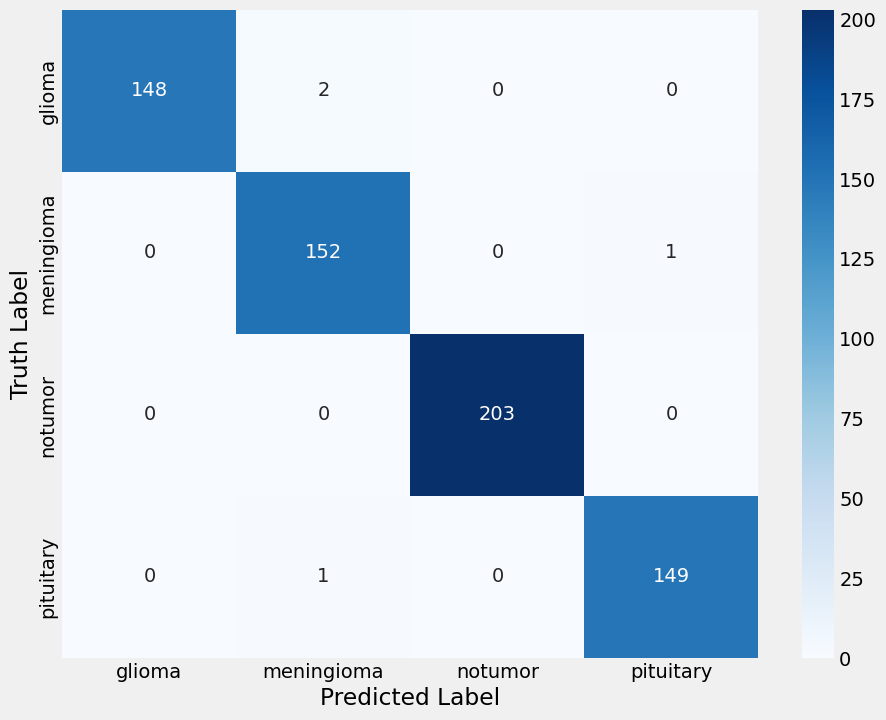

In [17]:
preds = model.predict(ts_gen)
y_pred = np.argmax(preds, axis=1)
cm = confusion_matrix(ts_gen.classes, y_pred)
labels = list(class_dict.keys())
plt.figure(figsize=(10,8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=labels, yticklabels=labels)
plt.xlabel('Predicted Label')
plt.ylabel('Truth Label')
plt.show()

In [18]:
clr = classification_report(ts_gen.classes, y_pred)
print(clr)

              precision    recall  f1-score   support

           0       1.00      0.99      0.99       150
           1       0.98      0.99      0.99       153
           2       1.00      1.00      1.00       203
           3       0.99      0.99      0.99       150

    accuracy                           0.99       656
   macro avg       0.99      0.99      0.99       656
weighted avg       0.99      0.99      0.99       656



In [19]:
for layer in model.layers:
    print(layer.name)

input_layer
block1_conv1
block1_conv1_bn
block1_conv1_act
block1_conv2
block1_conv2_bn
block1_conv2_act
block2_sepconv1
block2_sepconv1_bn
block2_sepconv2_act
block2_sepconv2
block2_sepconv2_bn
conv2d
block2_pool
batch_normalization
add
block3_sepconv1_act
block3_sepconv1
block3_sepconv1_bn
block3_sepconv2_act
block3_sepconv2
block3_sepconv2_bn
conv2d_1
block3_pool
batch_normalization_1
add_1
block4_sepconv1_act
block4_sepconv1
block4_sepconv1_bn
block4_sepconv2_act
block4_sepconv2
block4_sepconv2_bn
conv2d_2
block4_pool
batch_normalization_2
add_2
block5_sepconv1_act
block5_sepconv1
block5_sepconv1_bn
block5_sepconv2_act
block5_sepconv2
block5_sepconv2_bn
block5_sepconv3_act
block5_sepconv3
block5_sepconv3_bn
add_3
block6_sepconv1_act
block6_sepconv1
block6_sepconv1_bn
block6_sepconv2_act
block6_sepconv2
block6_sepconv2_bn
block6_sepconv3_act
block6_sepconv3
block6_sepconv3_bn
add_4
block7_sepconv1_act
block7_sepconv1
block7_sepconv1_bn
block7_sepconv2_act
block7_sepconv2
block7_sepco

In [20]:
from tensorflow.keras.preprocessing.image import load_img, img_to_array, ImageDataGenerator
from sklearn.feature_selection import SelectFromModel

In [21]:
data_dir = "/kaggle/input/brain-tumor-mri-dataset/"
train_path = os.path.join(data_dir, "Training")
test_path = os.path.join(data_dir, "Testing")
img_size = (299, 299)
batch_size = 16
num_classes = 4

all_images = []
all_labels = []
class_names = sorted(os.listdir(train_path))  # ['glioma', 'meningioma', 'notumor', 'pituitary']
print("Loading images...")
for class_idx, class_name in enumerate(class_names):
    train_class_path = os.path.join(train_path, class_name)
    for img_name in os.listdir(train_class_path):
        img_path = os.path.join(train_class_path, img_name)
        img = load_img(img_path, target_size=img_size)
        img_array = img_to_array(img) / 255.0
        all_images.append(img_array)
        all_labels.append(class_idx)
    test_class_path = os.path.join(test_path, class_name)
    for img_name in os.listdir(test_class_path):
        img_path = os.path.join(test_class_path, img_name)
        img = load_img(img_path, target_size=img_size)
        img_array = img_to_array(img) / 255.0
        all_images.append(img_array)
        all_labels.append(class_idx)

all_images = np.array(all_images, dtype='float16')
all_labels = np.array(all_labels)
print(f"Loaded {all_images.shape[0]} images with shape {all_images.shape[1:]}")

Loading images...
Loaded 7023 images with shape (299, 299, 3)


In [22]:
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

In [23]:
X_train, X_test, y_train, y_test = train_test_split(
    all_images, all_labels, test_size=0.2, random_state=42, stratify=all_labels
)

print(f"Training set: {X_train.shape[0]} images")
print(f"Test set: {X_test.shape[0]} images")

Training set: 5618 images
Test set: 1405 images


In [24]:
import gc
del all_images, all_labels


In [25]:
gc.collect()

6118

In [26]:
feature_extractor = Model(inputs=model.input, outputs=model.layers[-5].output)

In [27]:
train_features = feature_extractor.predict(X_train)
test_features = feature_extractor.predict(X_test)

175/176 ━━━━━━━━━━━━━━━━━━━━ 0s 106ms/step

E0000 00:00:1747238762.199017      64 gpu_timer.cc:82] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1747238762.436592      64 gpu_timer.cc:82] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


176/176 ━━━━━━━━━━━━━━━━━━━━ 27s 139ms/step
43/44 ━━━━━━━━━━━━━━━━━━━━ 0s 106ms/step

E0000 00:00:1747238777.091178      61 gpu_timer.cc:82] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1747238777.331934      61 gpu_timer.cc:82] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1747238777.989928      61 gpu_timer.cc:82] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1747238778.255810      61 gpu_timer.cc:82] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


44/44 ━━━━━━━━━━━━━━━━━━━━ 11s 254ms/step


In [28]:
scaler = StandardScaler()
X_train_features = scaler.fit_transform(train_features)
X_test_features = scaler.transform(test_features)

In [29]:
rf_feature_selector = RandomForestClassifier(n_estimators=100, random_state=42)
rf_feature_selector.fit(X_train_features, y_train)
selector = SelectFromModel(rf_feature_selector, threshold="median", prefit=True)
X_train_selected = selector.transform(X_train_features)
X_test_selected = selector.transform(X_test_features)
print(f"Random Forest Reduced Shape: {X_train_selected.shape}")

del train_features, test_features, X_train_features, X_test_features
gc.collect()

Random Forest Reduced Shape: (5618, 2048)


1122

In [30]:
methods = {
    'Random Forest': X_train_selected,
    'Decision Trees': None,
    'Z-score': None,
    'Random Forest Gini': None
}

In [31]:
dt = DecisionTreeClassifier(random_state=42, class_weight='balanced')
dt.fit(X_train_selected, y_train)
dt_importances = dt.feature_importances_
dt_indices = np.argsort(dt_importances)[::-1][:1000]
methods['Decision Trees'] = X_train_selected[:, dt_indices]

In [32]:
z_scores = np.abs(zscore(X_train_selected, axis=0))
mean_z_scores = np.mean(z_scores, axis=0)
z_indices = np.argsort(mean_z_scores)[::-1][:1000]
methods['Z-score'] = X_train_selected[:, z_indices]

In [33]:
rf_gini = RandomForestClassifier(n_estimators=100, random_state=42)
rf_gini.fit(X_train_selected, y_train)
rf_gini_importances = rf_gini.feature_importances_
rf_gini_indices = np.argsort(rf_gini_importances)[::-1][:1000]
methods['Random Forest Gini'] = X_train_selected[:, rf_gini_indices]

In [34]:
results = {}
for method, X_train_method in methods.items():
    X_test_method = (X_test_selected[:, rf_gini_indices] if method == 'Random Forest Gini'
                     else X_test_selected[:, dt_indices] if method == 'Decision Trees'
                     else X_test_selected[:, z_indices] if method == 'Z-score'
                     else X_test_selected)
    svm = SVC(kernel='rbf', random_state=42, class_weight='balanced')
    svm.fit(X_train_method, y_train)
    y_pred = svm.predict(X_test_method)
    accuracy = accuracy_score(y_test, y_pred)
    results[method] = accuracy
    print(f"{method} SVM Accuracy: {accuracy:.4f}")

Random Forest SVM Accuracy: 1.0000
Decision Trees SVM Accuracy: 1.0000
Z-score SVM Accuracy: 1.0000
Random Forest Gini SVM Accuracy: 1.0000


In [35]:
best_method = max(results, key=results.get)
X_train_best = methods[best_method]
X_test_best = (X_test_selected[:, rf_gini_indices] if best_method == 'Random Forest Gini'
               else X_test_selected[:, dt_indices] if best_method == 'Decision Trees'
               else X_test_selected[:, z_indices] if best_method == 'Z-score'
               else X_test_selected)

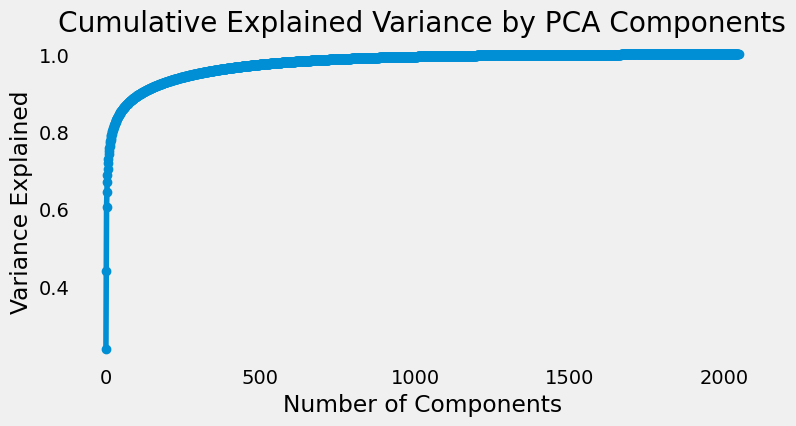

Optimal PCA components: 297


In [36]:
pca = PCA()
pca.fit(X_train_best)
explained_variance = np.cumsum(pca.explained_variance_ratio_)
plt.figure(figsize=(8, 4))
plt.plot(explained_variance, marker='o')
plt.title('Cumulative Explained Variance by PCA Components')
plt.xlabel('Number of Components')
plt.ylabel('Variance Explained')
plt.grid()
plt.savefig('/kaggle/working/pca_elbow.png')
plt.show()
plt.close()

optimal_components = np.argmax(explained_variance >= 0.95) + 1
print(f"Optimal PCA components: {optimal_components}")

pca = PCA(n_components=optimal_components)
X_train_pca = pca.fit_transform(X_train_best)
X_test_pca = pca.transform(X_test_best)


In [37]:
param_grid = {'C': [0.1, 1, 10], 'gamma': ['scale', 'auto', 0.001]}
grid = GridSearchCV(SVC(kernel='rbf', class_weight='balanced', probability = True), param_grid, cv=3)
grid.fit(X_train_pca, y_train)
print("Best SVM Parameters:", grid.best_params_)
svm = grid.best_estimator_

svm.fit(X_train_pca, y_train)
y_pred_final = svm.predict(X_test_pca)
final_accuracy = accuracy_score(y_test, y_pred_final)
print("Final SVM Accuracy with Best Method + PCA:", final_accuracy)
print("Final SVM Classification Report:\n", classification_report(y_test, y_pred_final, target_names=class_names))

Best SVM Parameters: {'C': 1, 'gamma': 'scale'}
Final SVM Accuracy with Best Method + PCA: 1.0
Final SVM Classification Report:
               precision    recall  f1-score   support

      glioma       1.00      1.00      1.00       324
  meningioma       1.00      1.00      1.00       329
     notumor       1.00      1.00      1.00       400
   pituitary       1.00      1.00      1.00       352

    accuracy                           1.00      1405
   macro avg       1.00      1.00      1.00      1405
weighted avg       1.00      1.00      1.00      1405



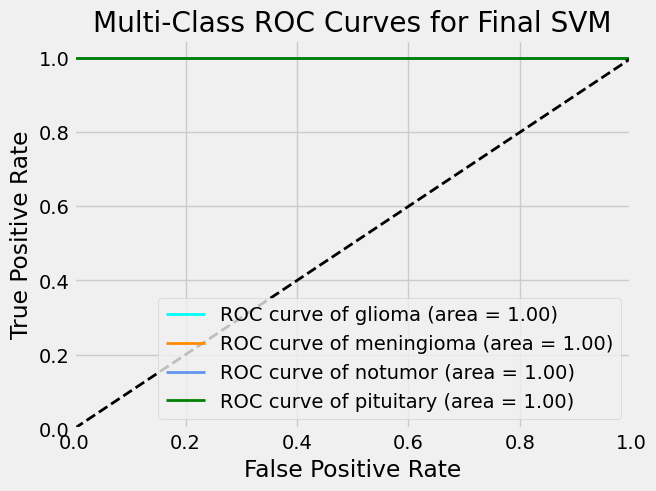

In [38]:
y_score = svm.decision_function(X_test_pca)
y_test_bin = label_binarize(y_test, classes=np.unique(y_test))
n_classes = y_test_bin.shape[1]
fpr = dict()
tpr = dict()
roc_auc = dict()
for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_score[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

plt.figure()
colors = ['aqua', 'darkorange', 'cornflowerblue', 'green']
for i, color in zip(range(n_classes), colors):
    plt.plot(fpr[i], tpr[i], color=color, lw=2,
             label=f'ROC curve of {class_names[i]} (area = {roc_auc[i]:.2f})')
plt.plot([0, 1], [0, 1], 'k--', lw=2)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Multi-Class ROC Curves for Final SVM')
plt.legend(loc="lower right")
plt.savefig('/kaggle/working/multi_class_roc_curves.png')
plt.show()
plt.close()

In [39]:
import lime
from lime import lime_tabular
import shap

LIME Explanations for Selected Test Instances:

Explanation for test instance 0 (True label: meningioma, Predicted: meningioma)
PCA_3 > 0.15: 0.6557
-13.92 < PCA_2 <= -6.69: 0.0674
PCA_4 > 2.17: 0.0258
-0.00 < PCA_164 <= 0.53: 0.0207
PCA_12 <= -2.21: -0.0199


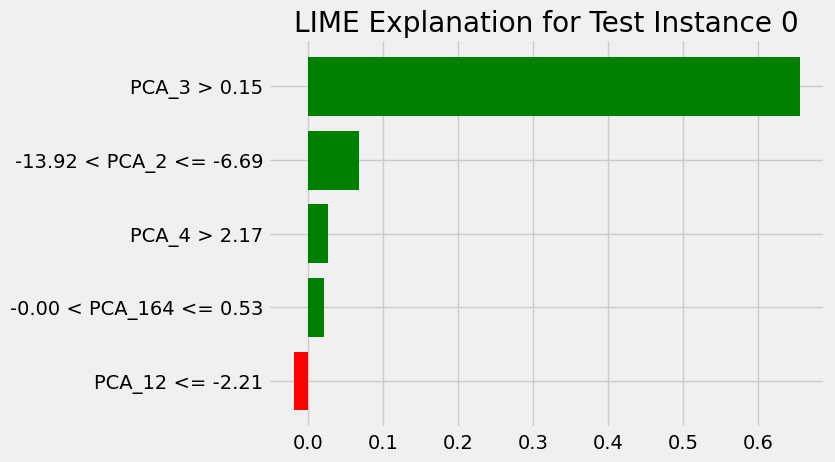


Explanation for test instance 1 (True label: meningioma, Predicted: meningioma)
PCA_3 > 0.15: 0.6464
-8.90 < PCA_1 <= 26.68: 0.0773
-13.92 < PCA_2 <= -6.69: 0.0765
PCA_224 > 0.45: -0.0187
-0.83 < PCA_68 <= 0.02: 0.0170


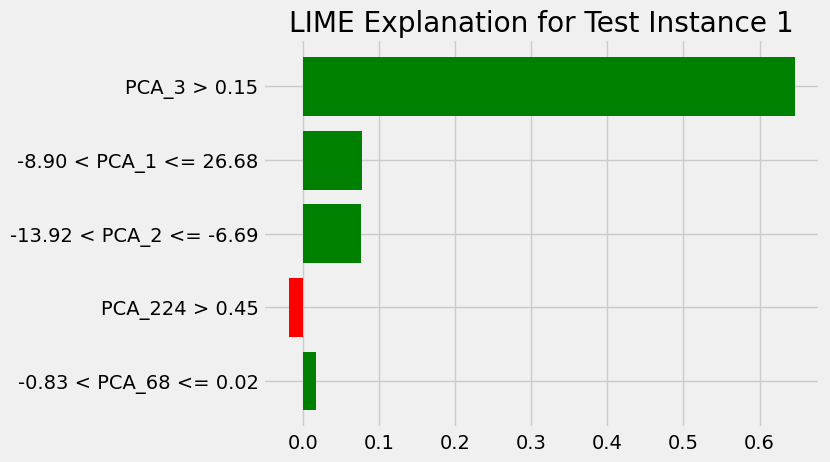


Explanation for test instance 2 (True label: glioma, Predicted: glioma)
PCA_3 <= -7.69: -0.2884
PCA_2 <= -13.92: 0.0520
PCA_131 > 0.59: -0.0307
PCA_75 <= -0.78: 0.0280
-0.90 < PCA_56 <= 0.03: -0.0256


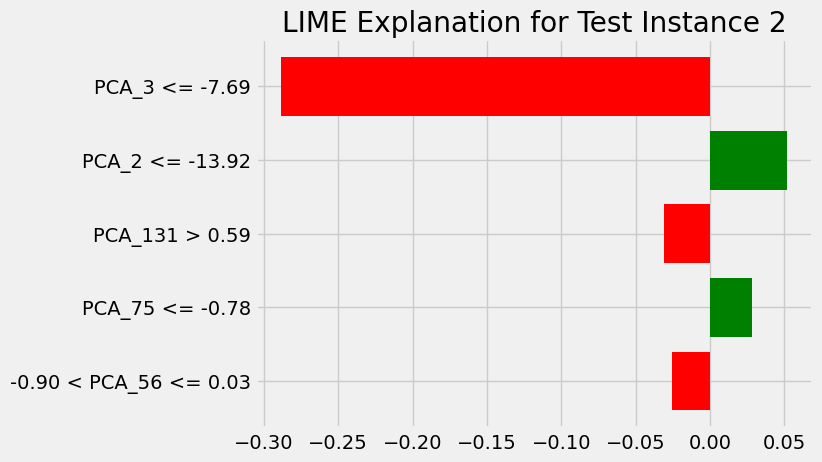

In [40]:
feature_names = [f'PCA_{i+1}' for i in range(X_train_pca.shape[1])]

lime_explainer = lime_tabular.LimeTabularExplainer(
    training_data=X_train_pca,
    feature_names=feature_names,
    class_names=class_names,
    mode='classification',
    random_state=42
)

print("LIME Explanations for Selected Test Instances:")
for idx in range(min(3, len(X_test_pca))):
    exp = lime_explainer.explain_instance(
        data_row=X_test_pca[idx],
        predict_fn=svm.predict_proba,
        num_features=5
    )
    print(f"\nExplanation for test instance {idx} (True label: {class_names[y_test[idx]]}, Predicted: {class_names[y_pred_final[idx]]})")
    for feature, weight in exp.as_list():
        print(f"{feature}: {weight:.4f}")
    exp.as_pyplot_figure()
    plt.title(f'LIME Explanation for Test Instance {idx}')
    plt.show()


  0%|          | 0/50 [00:00<?, ?it/s]


SHAP Summary Plot (Global Feature Importance):


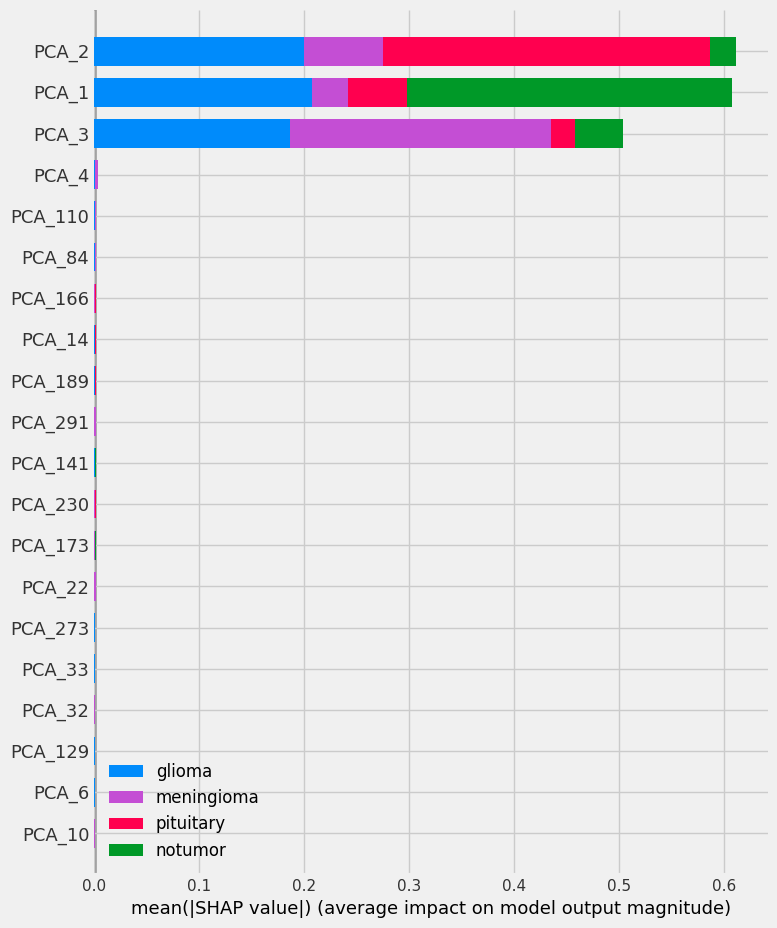


SHAP Explanation for Test Instance 0:


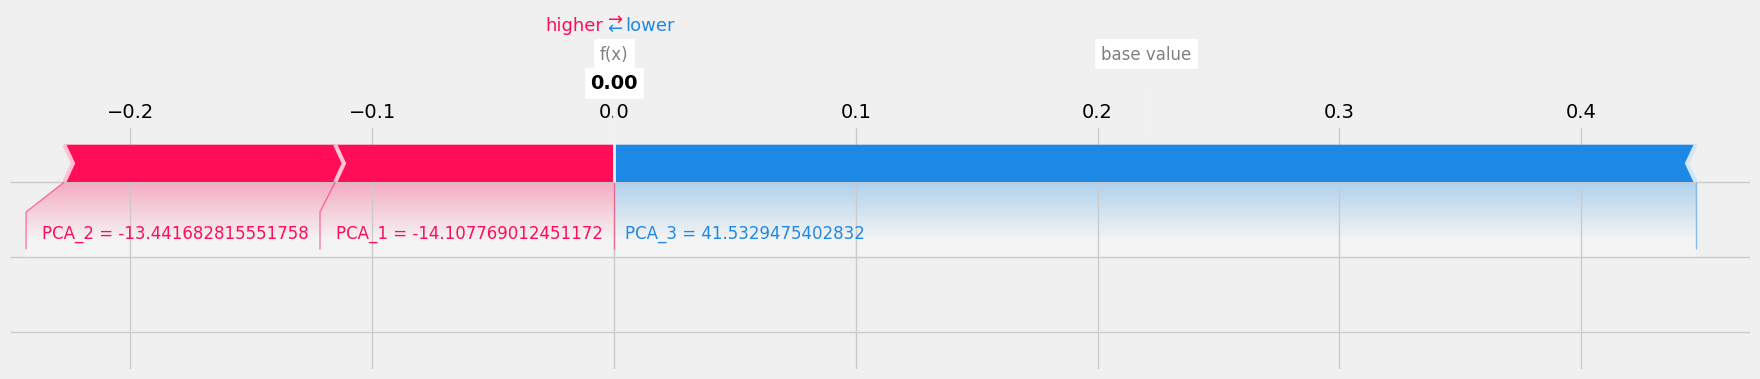

In [41]:
background_data = X_train_pca[np.random.choice(X_train_pca.shape[0], 100, replace=False)]
shap_explainer = shap.KernelExplainer(svm.predict_proba, background_data)
shap_values = shap_explainer.shap_values(X_test_pca[:50], nsamples=180)
print("\nSHAP Summary Plot (Global Feature Importance):")
shap.summary_plot(shap_values, X_test_pca[:50], feature_names=feature_names, class_names=class_names, plot_type="bar")
plt.show()
print("\nSHAP Explanation for Test Instance 0:")
shap.force_plot(shap_explainer.expected_value[0], shap_values[0][0], X_test_pca[0], feature_names=feature_names, matplotlib=True)
plt.show()


Partial Dependence Plots for Top PCA Components:


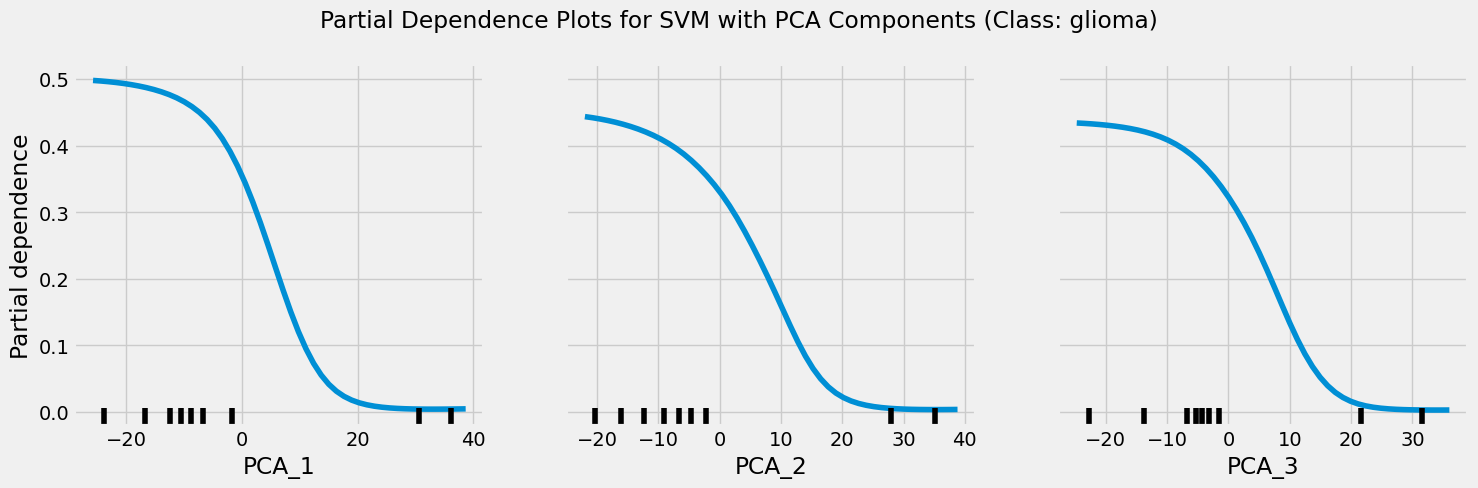

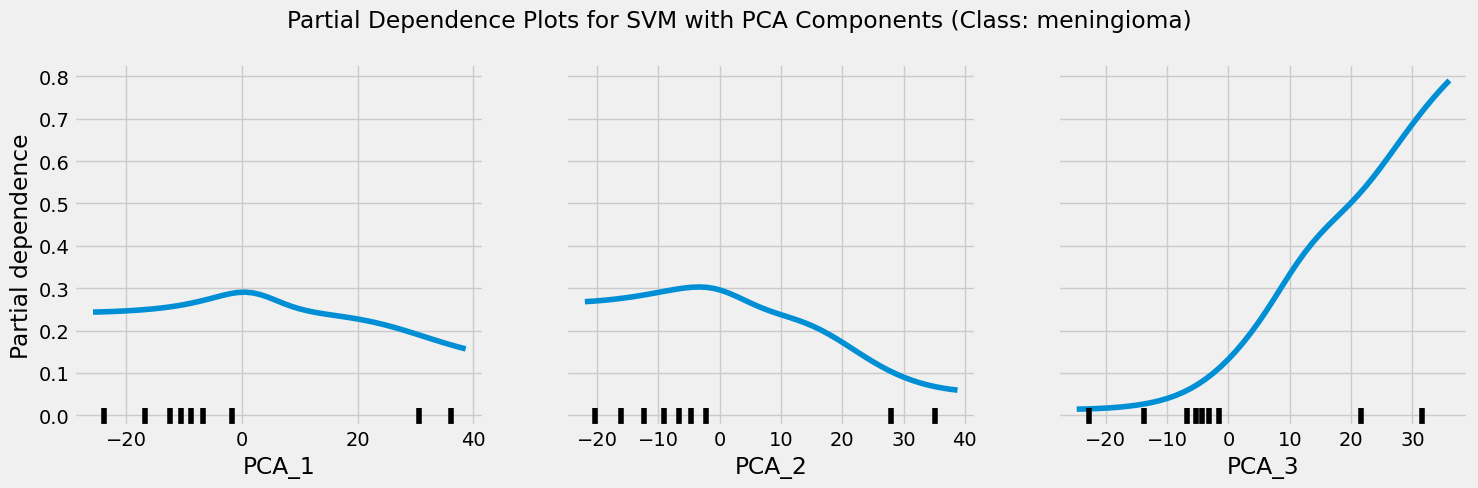

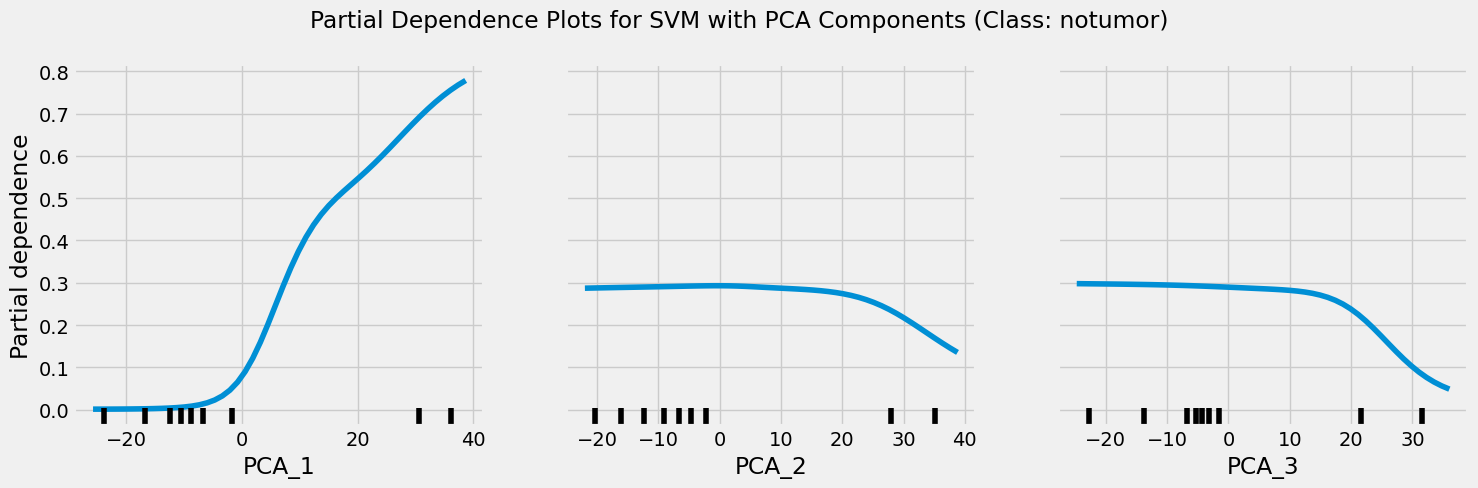

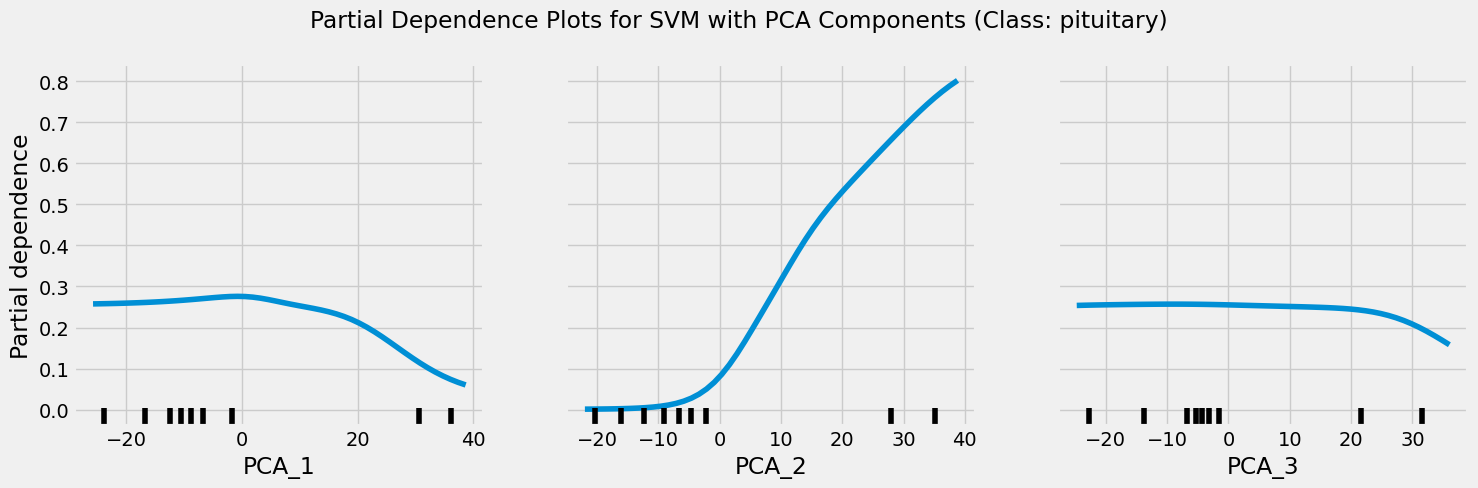

In [42]:
from sklearn.inspection import PartialDependenceDisplay
print("\nPartial Dependence Plots for Top PCA Components:")
features_to_plot = [0, 1, 2]
for class_idx, class_name in enumerate(class_names):
    fig, ax = plt.subplots(figsize=(15, 5))
    PartialDependenceDisplay.from_estimator(
        estimator=svm,
        X=X_train_pca,
        features=features_to_plot,
        feature_names=feature_names,
        target=class_idx,
        grid_resolution=50,
        ax=ax
    )
    plt.suptitle(f'Partial Dependence Plots for SVM with PCA Components (Class: {class_name})')
    plt.tight_layout()
    plt.show()

In [43]:
from sklearn.inspection import PartialDependenceDisplay, permutation_importance


Permutation Importance for PCA Components:


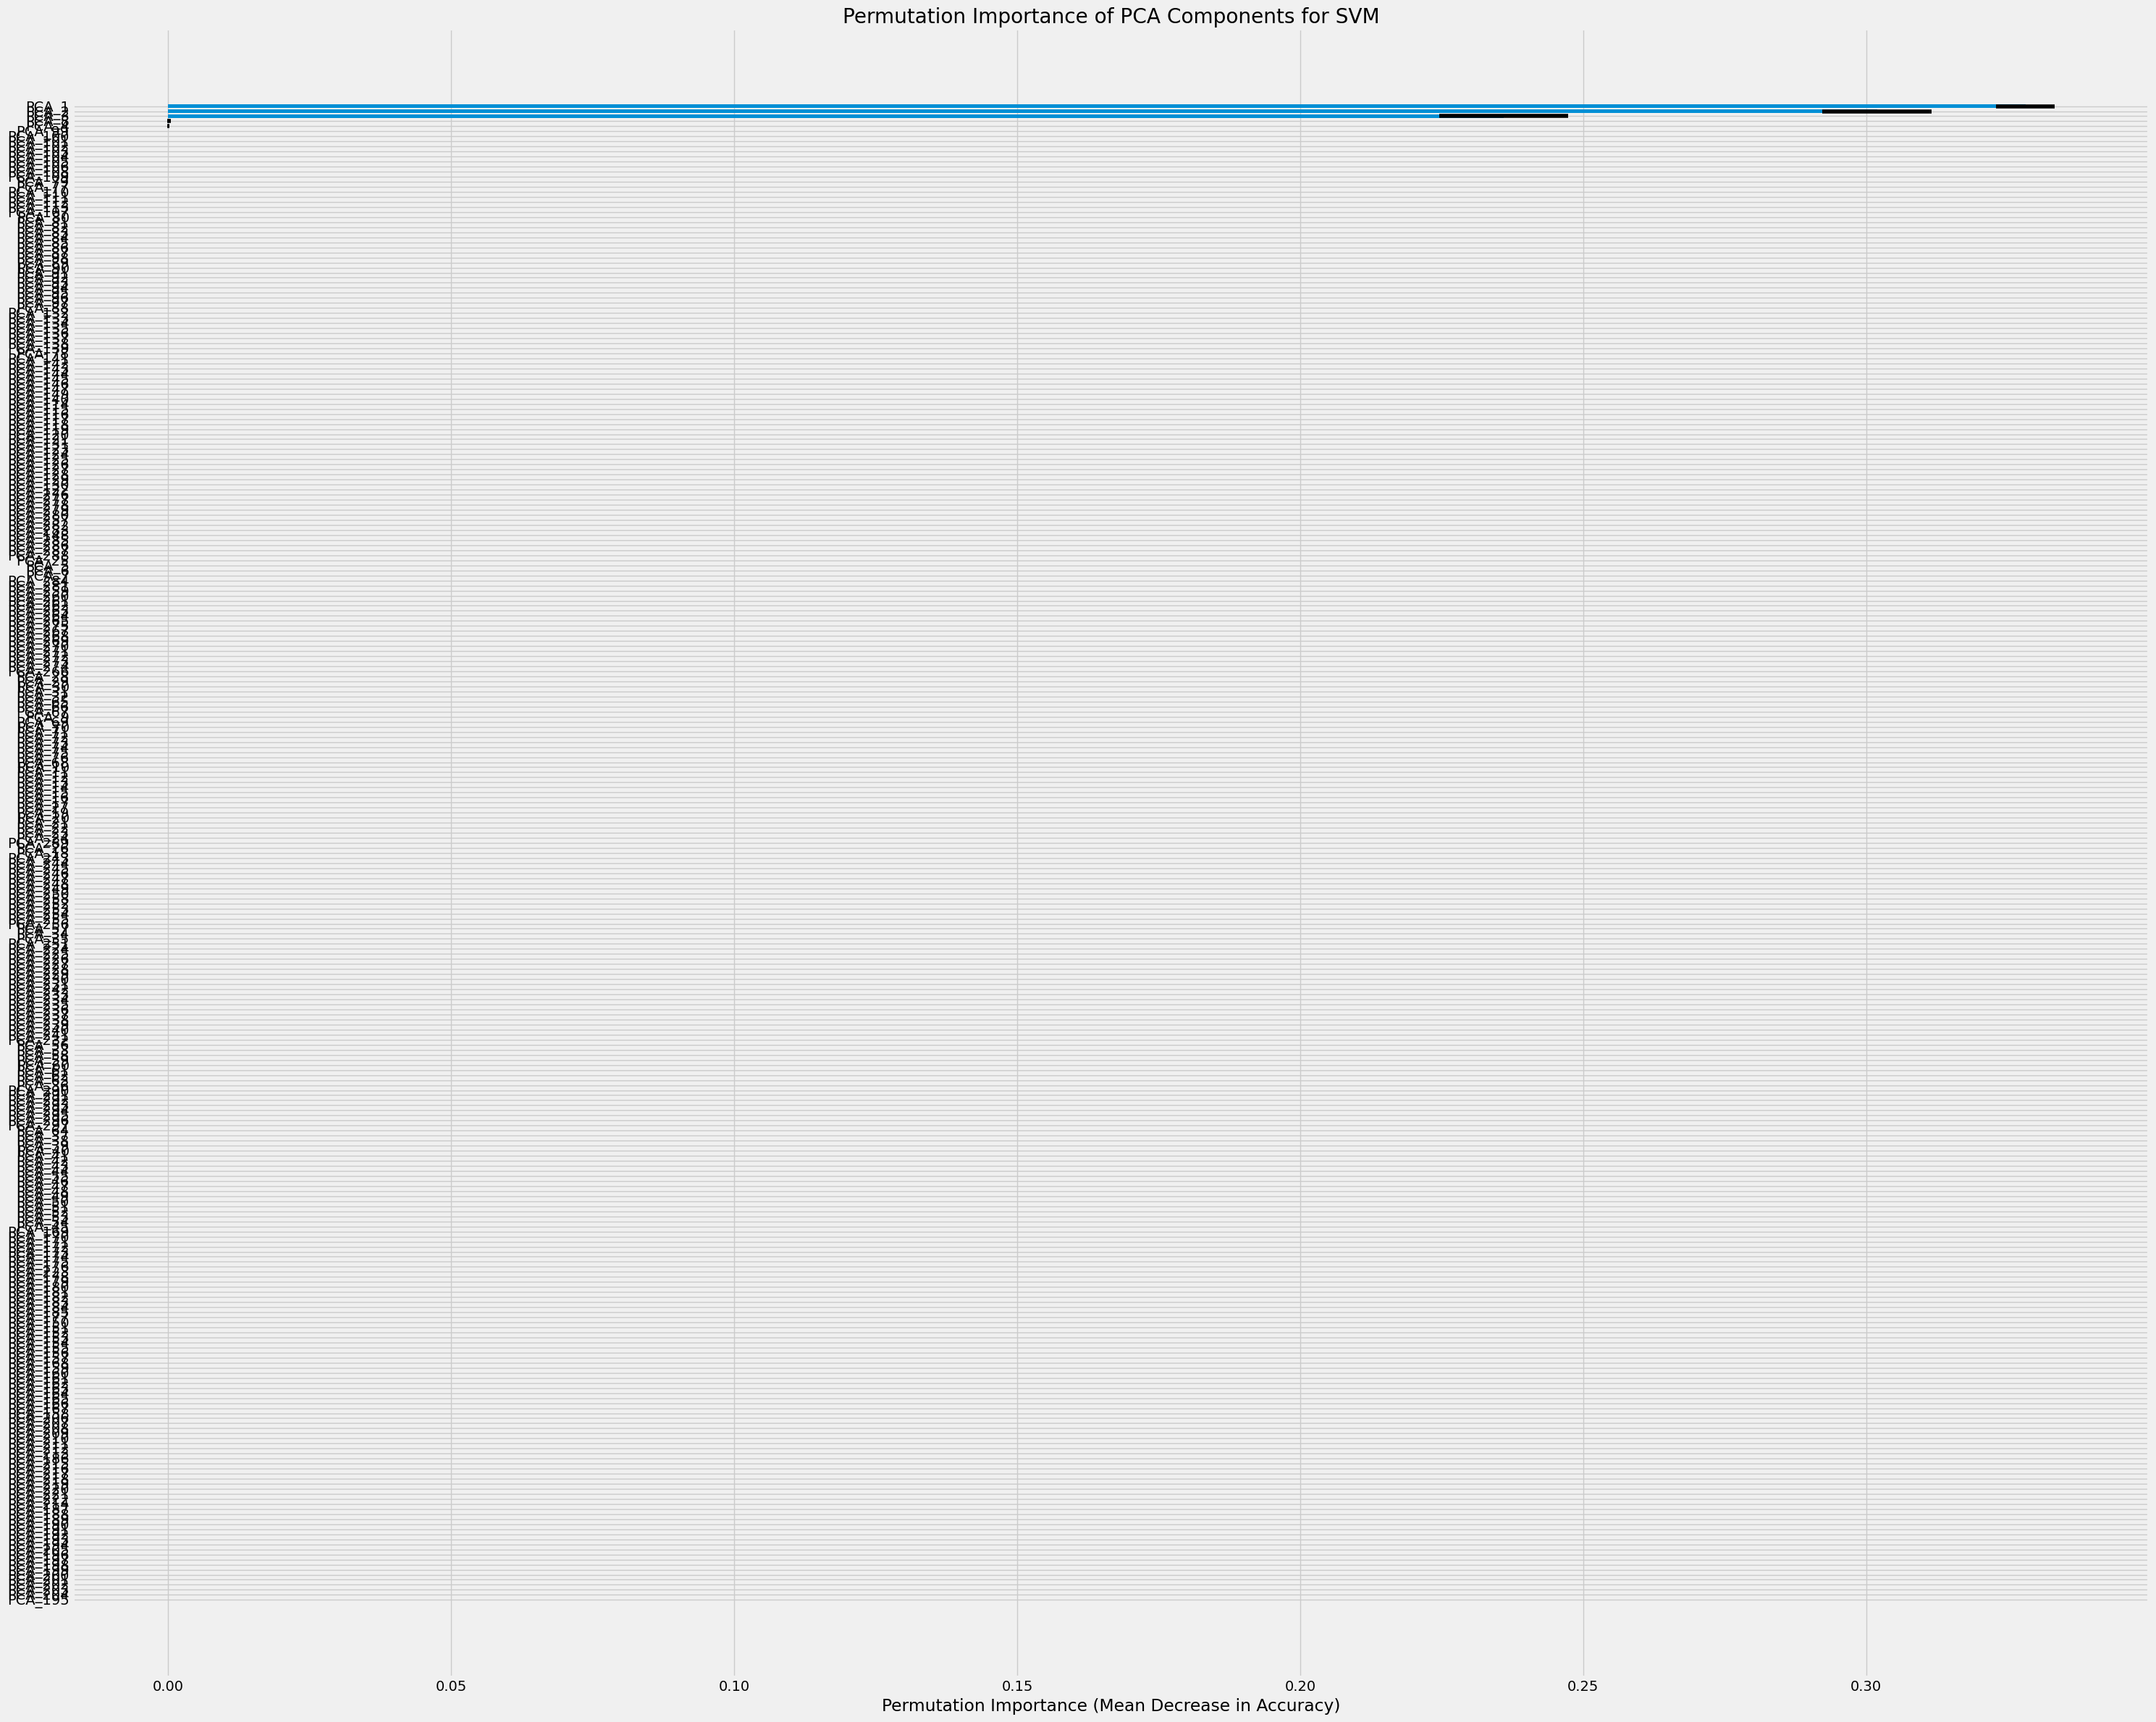

Permutation Importance Values:
PCA_1: 0.3281 ± 0.0051
PCA_2: 0.3019 ± 0.0096
PCA_3: 0.2359 ± 0.0114
PCA_8: 0.0001 ± 0.0003
PCA_4: 0.0001 ± 0.0002
PCA_99: 0.0000 ± 0.0000
PCA_100: 0.0000 ± 0.0000
PCA_101: 0.0000 ± 0.0000
PCA_102: 0.0000 ± 0.0000
PCA_103: 0.0000 ± 0.0000
PCA_104: 0.0000 ± 0.0000
PCA_105: 0.0000 ± 0.0000
PCA_106: 0.0000 ± 0.0000
PCA_108: 0.0000 ± 0.0000
PCA_109: 0.0000 ± 0.0000
PCA_79: 0.0000 ± 0.0000
PCA_77: 0.0000 ± 0.0000
PCA_110: 0.0000 ± 0.0000
PCA_111: 0.0000 ± 0.0000
PCA_112: 0.0000 ± 0.0000
PCA_113: 0.0000 ± 0.0000
PCA_107: 0.0000 ± 0.0000
PCA_80: 0.0000 ± 0.0000
PCA_81: 0.0000 ± 0.0000
PCA_82: 0.0000 ± 0.0000
PCA_83: 0.0000 ± 0.0000
PCA_84: 0.0000 ± 0.0000
PCA_85: 0.0000 ± 0.0000
PCA_86: 0.0000 ± 0.0000
PCA_87: 0.0000 ± 0.0000
PCA_98: 0.0000 ± 0.0000
PCA_89: 0.0000 ± 0.0000
PCA_90: 0.0000 ± 0.0000
PCA_91: 0.0000 ± 0.0000
PCA_92: 0.0000 ± 0.0000
PCA_93: 0.0000 ± 0.0000
PCA_94: 0.0000 ± 0.0000
PCA_95: 0.0000 ± 0.0000
PCA_96: 0.0000 ± 0.0000
PCA_97: 0.0000 ± 0.0000


In [44]:
print("\nPermutation Importance for PCA Components:")
perm_importance = permutation_importance(svm, X_test_pca, y_test, n_repeats=10, random_state=42, n_jobs=-1)
sorted_idx = perm_importance.importances_mean.argsort()
plt.figure(figsize=(30, 24))
plt.barh(range(len(sorted_idx)), perm_importance.importances_mean[sorted_idx], xerr=perm_importance.importances_std[sorted_idx], align='center')
plt.yticks(range(len(sorted_idx)), [feature_names[i] for i in sorted_idx])
plt.xlabel('Permutation Importance (Mean Decrease in Accuracy)')
plt.title('Permutation Importance of PCA Components for SVM')
plt.tight_layout()
plt.show()
print("Permutation Importance Values:")
for i in sorted_idx[::-1]:
    print(f"{feature_names[i]}: {perm_importance.importances_mean[i]:.4f} ± {perm_importance.importances_std[i]:.4f}")